# Finland Population Analysis 1970–2025
### How is Finland's population likely to change over the next 10–20 years?

I used Finnish population data from Statistics Finland - https://pxdata.stat.fi/PxWeb/pxweb/en/StatFin/ to analyze births, deaths, migration and age structure — then build an LSTM model to forecast population up to 2040.

**Datasets:**
- Birth_and_Death_1990-2024.csv
- Emigration_and_Immigration_1990-2024.csv
- Population_by_age_group_1970-2025.csv
- Citizenship_by_municipality_1990-2025.csv

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42 # for prevent randomness in results
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Loading the Data

All files use semicolons as separators and latin-1 encoding. The first two rows are a title and blank line so need skip them.

In [2]:
# births and deaths
bd = pd.read_csv("Birth_and_Death_1990-2024.csv", sep=";", encoding="latin-1", skiprows=2)
bd.columns = ["year", "births", "deaths"]
bd["year"] = bd["year"].astype(int)
bd["natural_change"] = bd["births"] - bd["deaths"] # Calculate natural change by subtracting deaths from births

print(bd.head())

   year  births  deaths  natural_change
0  1990   65549   50058           15491
1  1991   65395   49294           16101
2  1992   66731   49844           16887
3  1993   64826   50988           13838
4  1994   65231   48000           17231


In [3]:
# immigration and emigration
mig = pd.read_csv("Emigration_and_Immigration_1990-2024.csv", sep=";", encoding="latin-1", skiprows=2)
mig.columns = ["year", "immigration", "emigration"]
mig["year"] = mig["year"].astype(int)
mig["net_migration"] = mig["immigration"] - mig["emigration"] # Calculate net migration by subtracting emigration from immigration

print(mig.head())

   year  immigration  emigration  net_migration
0  1990        13558        6477           7081
1  1991        19001        5984          13017
2  1992        14554        6055           8499
3  1993        14795        6405           8390
4  1994        11611        8672           2939


In [4]:
# population by age group
age = pd.read_csv("Population_by_age_group_1970-2025.csv", sep=";", encoding="latin-1", skiprows=2)

# shorten column names to just the age band
age.columns = ["year"] + [
    col.split("Total ")[1].split(" Population")[0].strip()
    for col in age.columns[1:]
]
age["year"] = age["year"].astype(int)

# add total population column
age_cols = [c for c in age.columns if c != "year"]
age["total_population"] = age[age_cols].sum(axis=1)

print(age[["year", "total_population"]].head())
print("Age groups:", list(age.columns[1:-1]))

   year  total_population
0  1970           4598336
1  1971           4625912
2  1972           4653401
3  1973           4678761
4  1974           4702387
Age groups: ['0 - 4', '5 - 9', '10 - 14', '15 - 19', '20 - 24', '25 - 29', '30 - 34', '35 - 39', '40 - 44', '45 - 49', '50 - 54', '55 - 59', '60 - 64', '65 - 69', '70 - 74', '75 - 79', '80 - 84', '85 -']


In [5]:
# population by municipality
mun = pd.read_csv("Citizenship_by_municipality_1990-2025.csv", sep=";", encoding="latin-1", skiprows=2)
mun = mun.drop(columns=["Nationality"]) # we dont need this column for our task

# rename columns to just the year number
mun.columns = ["municipality"] + [
    int(col.split("Total ")[1].split(" Population")[0].strip())
    for col in mun.columns[1:]
]

# change from wide to long format
mun_long = mun.melt(id_vars="municipality", var_name="year", value_name="population")
mun_long["year"] = mun_long["year"].astype(int)

print(f"Municipalities: {mun_long['municipality'].nunique()}, Years: {mun_long['year'].nunique()}")
print(mun_long.head())

Municipalities: 308, Years: 36
  municipality  year  population
0         Akaa  1990       16048
1     Alajärvi  1990       11963
2    Alavieska  1990        3072
3       Alavus  1990       13785
4     Asikkala  1990        8822


## 3. Combining into One Table

In [6]:
# merge births/deaths and migration on year
national = bd.merge(mig, on="year", how="inner")

# add total population from age dataset
national = national.merge(age[["year", "total_population"]], on="year", how="inner")

# calculate derived columns
national["total_change"] = national["natural_change"] + national["net_migration"]

# migration share = how much of the total growth came from migration
national["migration_share"] = (
    national["net_migration"] / national["total_change"].replace(0, np.nan) * 100
).round(1)

print(national[["year","births","deaths","natural_change","net_migration","total_change","migration_share"]].tail(8))

    year  births  deaths  natural_change  net_migration  total_change  \
27  2017   50321   53722           -3401          14824         11423   
28  2018   47577   54527           -6950          11965          5015   
29  2019   45613   53949           -8336          15495          7159   
30  2020   46463   55488           -9025          17814          8789   
31  2021   49594   57659           -8065          22905         14840   
32  2022   44951   63219          -18268          34363         16095   
33  2023   43383   61339          -17956          57914         39958   
34  2024   43720   58267          -14547          47051         32504   

    migration_share  
27            129.8  
28            238.6  
29            216.4  
30            202.7  
31            154.3  
32            213.5  
33            144.9  
34            144.8  


## 4. Visualizing the Data

### 4.1 Births and Deaths over time

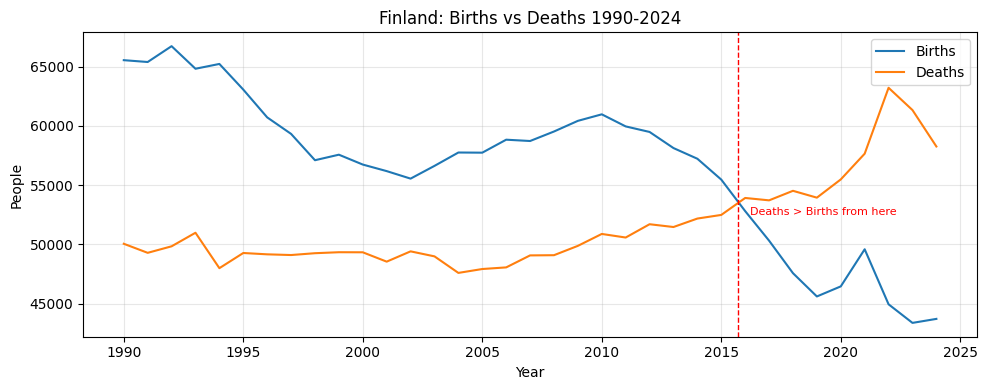

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(national["year"], national["births"], label="Births")
plt.plot(national["year"], national["deaths"], label="Deaths")
plt.axvline(2015.7, color="red", linestyle="--", linewidth=1)
plt.text(2016.2, 52500, "Deaths > Births from here", fontsize=8, color="red") # annotate the point where deaths start to exceed births
plt.title("Finland: Births vs Deaths 1990-2024")
plt.xlabel("Year")
plt.ylabel("People")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Net Migration

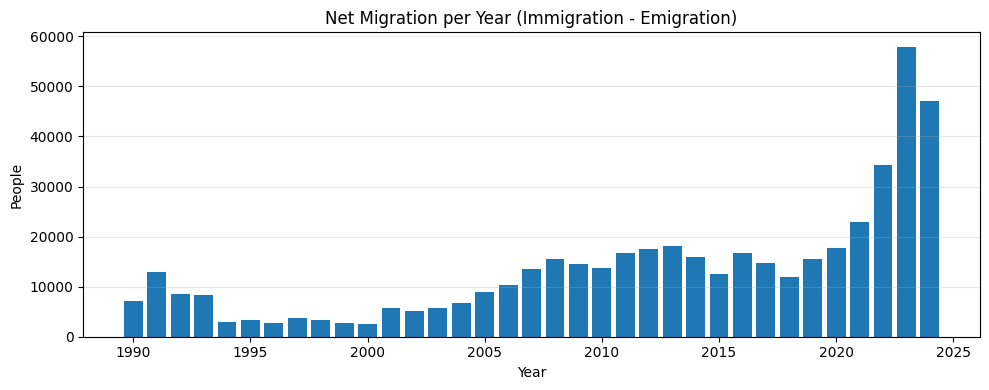

In [8]:
plt.figure(figsize=(10, 4))
plt.bar(national["year"], national["net_migration"])
plt.title("Net Migration per Year (Immigration - Emigration)")
plt.xlabel("Year")
plt.ylabel("People")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 4.3 Age structure — how the population has aged since 1970

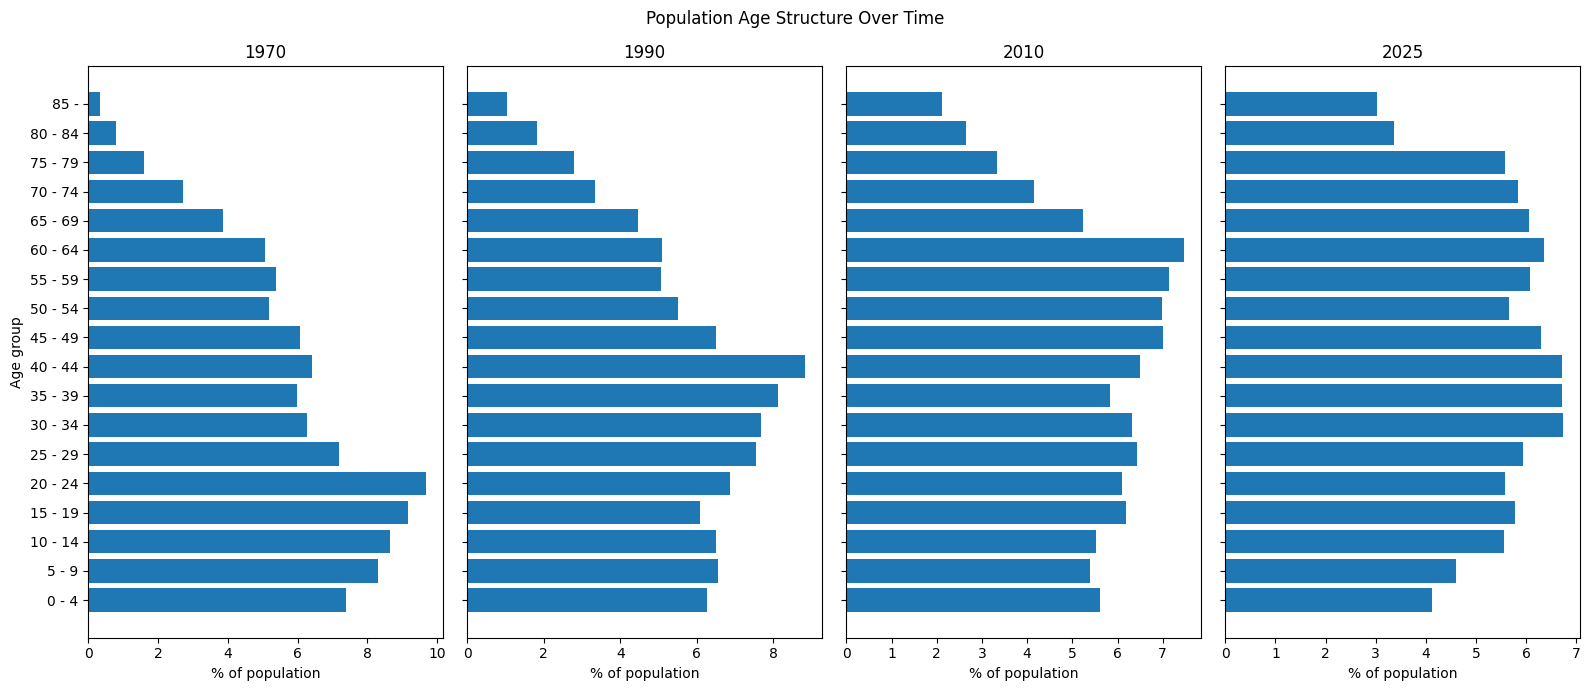

In [9]:
age_group_list = [
    "0 - 4","5 - 9","10 - 14","15 - 19","20 - 24","25 - 29",
    "30 - 34","35 - 39","40 - 44","45 - 49","50 - 54","55 - 59",
    "60 - 64","65 - 69","70 - 74","75 - 79","80 - 84","85 -"
]

fig, axes = plt.subplots(1, 4, figsize=(16, 7), sharey=True)
fig.suptitle("Population Age Structure Over Time")

for ax, year in zip(axes, [1970, 1990, 2010, 2025]):
    row = age.loc[age["year"] == year, age_group_list].squeeze()
    pct = (row / row.sum() * 100).values
    ax.barh(age_group_list, pct)
    ax.set_title(str(year))
    ax.set_xlabel("% of population")

axes[0].set_ylabel("Age group")
plt.tight_layout()
plt.show()

### 4.4 Top 10 growing and declining municipalities 1990-2025

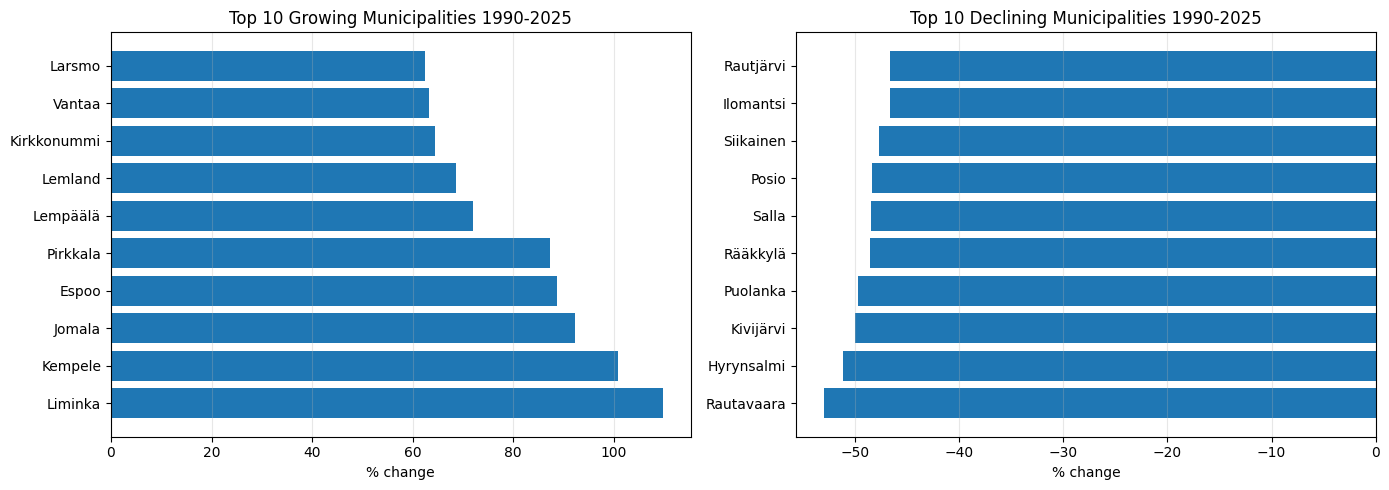

In [10]:
mun_change = mun_long[mun_long["year"].isin([1990, 2025])]
mun_pivot = mun_change.pivot(index="municipality", columns="year", values="population")
mun_pivot["change_pct"] = (mun_pivot[2025] - mun_pivot[1990]) / mun_pivot[1990] * 100

top10 = mun_pivot.nlargest(10, "change_pct")
bot10 = mun_pivot.nsmallest(10, "change_pct")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10.index, top10["change_pct"])
axes[0].set_title("Top 10 Growing Municipalities 1990-2025")
axes[0].set_xlabel("% change")
axes[0].grid(alpha=0.3, axis="x")

axes[1].barh(bot10.index, bot10["change_pct"])
axes[1].set_title("Top 10 Declining Municipalities 1990-2025")
axes[1].set_xlabel("% change")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## 5. Anomaly Detection
Used z-scores to find years where statistics were unusually different from the rest. <br>
A z-score above 2.0 means the value is more than 2 standard deviations away from the average — which counts as unusual.

In [11]:
anomaly_df = national[["year","natural_change","net_migration","total_change"]].copy()

for col in ["natural_change", "net_migration", "total_change"]:
    anomaly_df[f"z_{col}"] = stats.zscore(anomaly_df[col])

anomaly_df["is_anomaly"] = (
    (anomaly_df["z_natural_change"].abs() > 2.0) |
    (anomaly_df["z_net_migration"].abs()  > 2.0) |
    (anomaly_df["z_total_change"].abs()   > 2.0)
)

print("Anomalous years:")
print(anomaly_df[anomaly_df["is_anomaly"]][["year","natural_change","net_migration","total_change"]])

Anomalous years:
    year  natural_change  net_migration  total_change
32  2022          -18268          34363         16095
33  2023          -17956          57914         39958
34  2024          -14547          47051         32504


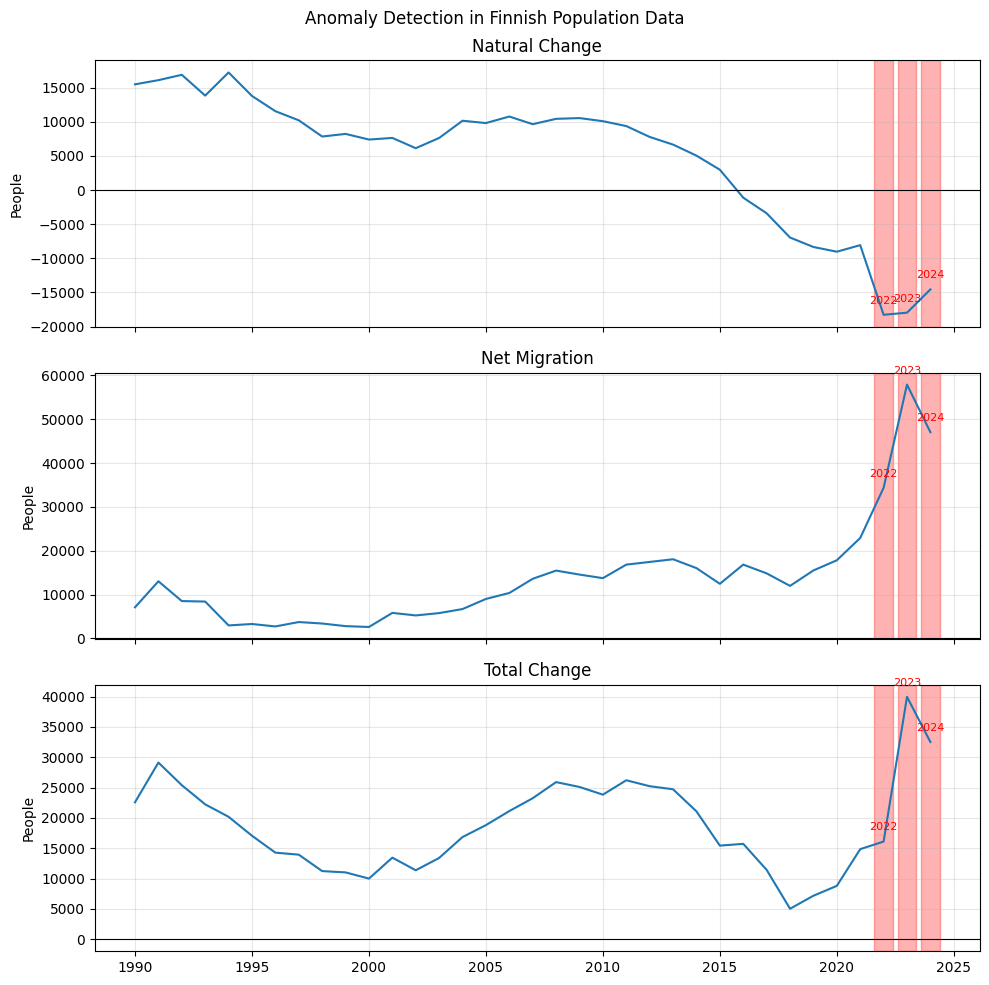

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.suptitle("Anomaly Detection in Finnish Population Data")

for ax, col, title in zip(axes,
        ["natural_change", "net_migration", "total_change"],
        ["Natural Change", "Net Migration", "Total Change"]):

    ax.plot(anomaly_df["year"], anomaly_df[col])

    for _, row in anomaly_df[anomaly_df["is_anomaly"]].iterrows():
        ax.axvspan(row["year"] - 0.4, row["year"] + 0.4, alpha=0.3, color="red")
        ax.annotate(str(int(row["year"])),
                    xy=(row["year"], row[col]),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=8, color="red") # highlight anomalous years in red

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("People")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. LSTM Forecast Model
Used an LSTM (Long Short-Term Memory) neural network to predict future population.
LSTM is good for time series because it can remember patterns from previous years when making predictions.

Note: I found only 35 years of data which is quite small for deep learning, so kept the model small and used dropout to avoid overfitting.

### 6.1 Prepare sequences for the LSTM

In [13]:
features = ["births","deaths","immigration","emigration",
            "natural_change","net_migration","total_population"]

df_model = national[["year"] + features].copy().reset_index(drop=True)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_model[features])

target_col = features.index("total_population")  # target

WINDOW = 5 # use 5 years of history to predict the next year's population
X, y = [], []
for i in range(WINDOW, len(scaled)):
    X.append(scaled[i-WINDOW:i])    # 5 years of all features
    y.append(scaled[i, target_col]) # next year population

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape) 
print("y shape:", y.shape)

split = len(X) - 5
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:] # keep last 5 years as test set to check accuracy
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

X shape: (30, 5, 7)
y shape: (30,)
Train: 25, Test: 5


### 6.2 Build the model

In [14]:
tf.random.set_seed(SEED)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, len(features))),
    Dropout(0.2),   # dropout to avoid overfitting
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

d:\Implementing_IoT_Pipeline\Machine Learning Task\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 6.3 Train the model

In [15]:
early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=8,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=0
)

### 6.4 Model learning curve

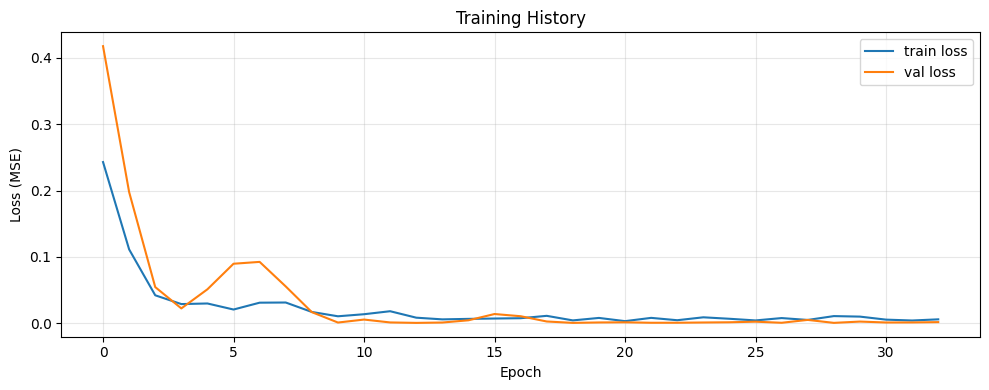

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
def inverse_population(scaled_values):
    dummy = np.zeros((len(scaled_values), len(features)))
    dummy[:, target_col] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_col]

y_pred_scaled = model.predict(X_test)
y_pred_actual = inverse_population(y_pred_scaled)
y_test_actual = inverse_population(y_test.reshape(-1, 1))

print("Test set results:")
for i, yr in enumerate(range(2020, 2025)):
    error = abs(y_test_actual[i] - y_pred_actual[i])
    pct   = error / y_test_actual[i] * 100
    print(f"  {yr}: Actual={y_test_actual[i]:>10,.0f}  Predicted={y_pred_actual[i]:>10,.0f}  Error={error:,.0f} ({pct:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Test set results:
  2020: Actual= 5,533,793  Predicted= 5,544,738  Error=10,945 (0.20%)
  2021: Actual= 5,548,241  Predicted= 5,560,649  Error=12,408 (0.22%)
  2022: Actual= 5,563,970  Predicted= 5,561,929  Error=2,041 (0.04%)
  2023: Actual= 5,603,851  Predicted= 5,587,213  Error=16,638 (0.30%)
  2024: Actual= 5,635,971  Predicted= 5,622,826  Error=13,145 (0.23%)


## 7. Forecasting 2025–2040
Projected population under three migration scenarios based on previous year data. <br>
Birth decline continues based on recent trend, and deaths slowly increase as the population ages.

| Scenario | Net migration/year |
|---|---|
| Low | 12,000 (pre-2015 average) |
| Baseline | 22,000 (2015-2021 average) |
| High | 40,000 (recent levels) |

In [19]:
scenarios = {
    "Low migration":  {"net_mig": 12000, "birth_trend": -600},
    "Baseline":       {"net_mig": 22000, "birth_trend": -400},
    "High migration": {"net_mig": 40000, "birth_trend": -200},
}

forecast = {}

for name, params in scenarios.items():
    pop    = national["total_population"].iloc[-1]  # start from 2024
    births = national["births"].iloc[-1]
    deaths = national["deaths"].iloc[-1]

    rows = [{"year": 2024, "population": pop, "natural_change": 0,
             "net_migration": 0, "total_change": 0}]

    for i, yr in enumerate(range(2025, 2041)):
        proj_births  = max(30000, births + params["birth_trend"] * (i + 1))
        proj_deaths  = min(70000, deaths + 300 * (i + 1))  # deaths rise slowly as population ages
        nat_change   = proj_births - proj_deaths
        total_change = nat_change + params["net_mig"]
        pop          = pop + total_change

        rows.append({
            "year": yr, "population": round(pop),
            "natural_change": round(nat_change),
            "net_migration": params["net_mig"],
            "total_change": round(total_change)
        })

    forecast[name] = pd.DataFrame(rows)

print(f"{'Year':<8}{'Low':>14}{'Baseline':>14}{'High':>14}")
print("-" * 50)
for yr in [2025, 2030, 2035, 2040]:
    row = f"{yr:<8}"
    for name in scenarios:
        pop = forecast[name].loc[forecast[name]["year"]==yr, "population"].values[0]
        row += f"{pop:>14,}"
    print(row)

Year               Low      Baseline          High
--------------------------------------------------
2025         5,632,524     5,642,724     5,660,924
2030         5,601,789     5,665,989     5,778,189
2035         5,548,554     5,671,754     5,882,954
2040         5,472,819     5,660,019     5,975,219


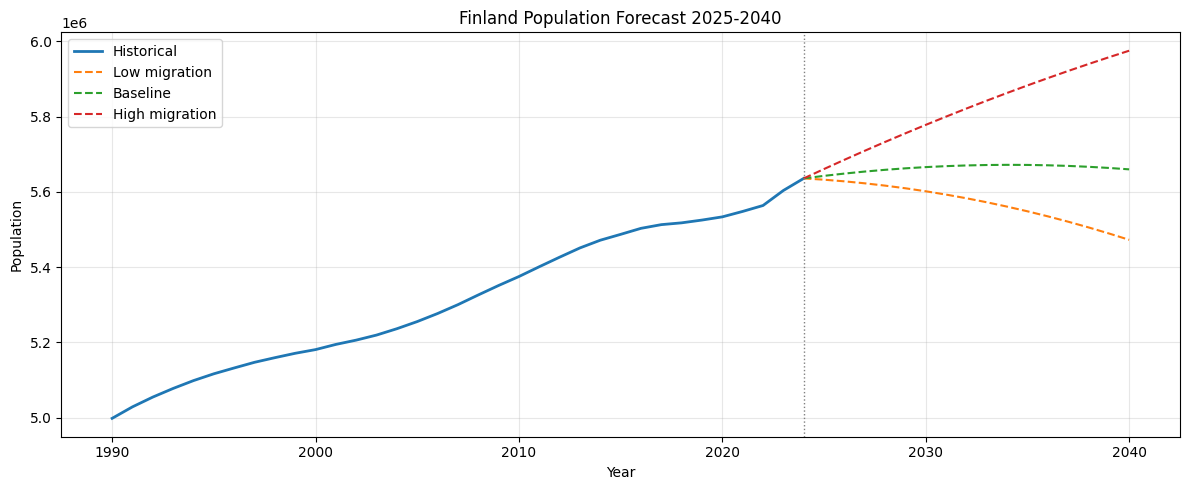

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(national["year"], national["total_population"], label="Historical", linewidth=2)

for name, df in forecast.items():
    plt.plot(df["year"], df["population"], linestyle="--", label=name)

plt.axvline(2024, color="gray", linestyle=":", linewidth=1)
plt.title("Finland Population Forecast 2025-2040")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Dashboard

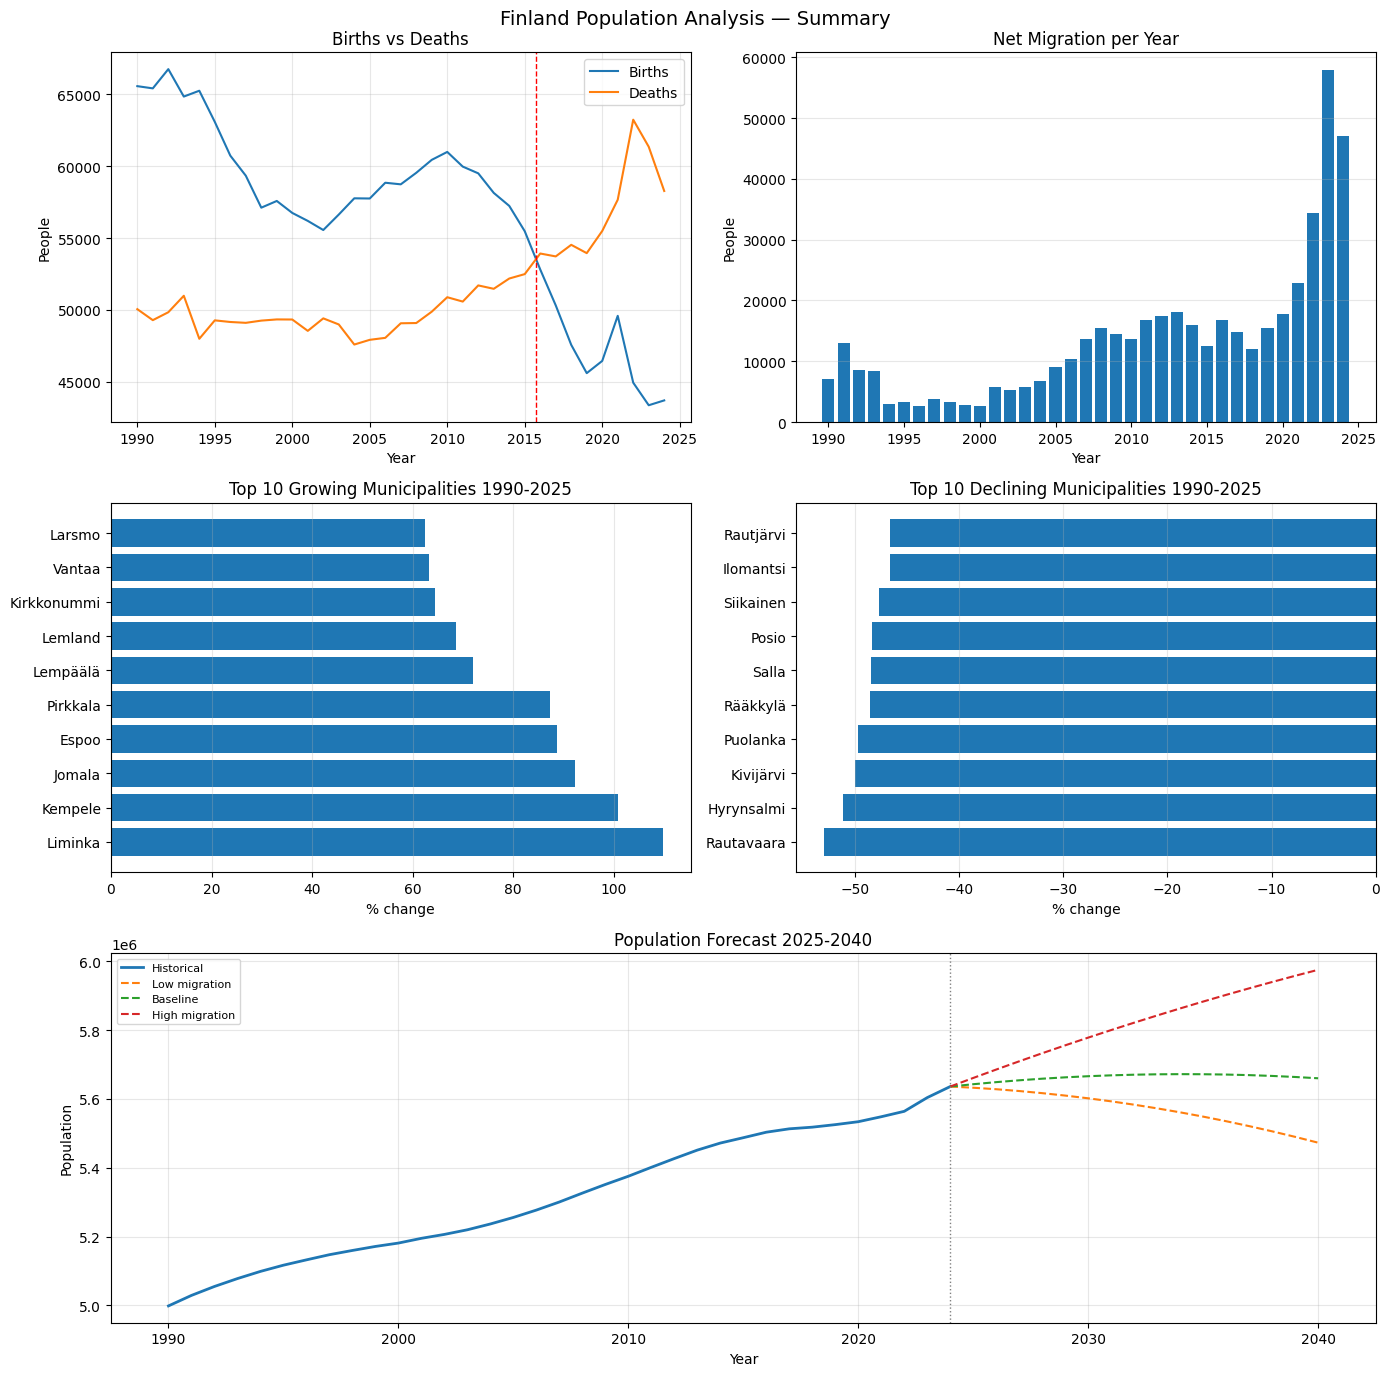

In [21]:
fig = plt.figure(figsize=(14, 14))
fig.suptitle("Finland Population Analysis — Summary", fontsize=14)

# row 1: births vs deaths and net migration
ax1 = fig.add_subplot(3, 2, 1)
ax1.plot(national["year"], national["births"], label="Births")
ax1.plot(national["year"], national["deaths"], label="Deaths")
ax1.axvline(2015.7, color="red", linestyle="--", linewidth=1)
ax1.set_title("Births vs Deaths")
ax1.set_xlabel("Year")
ax1.set_ylabel("People")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(3, 2, 2)
ax2.bar(national["year"], national["net_migration"])
ax2.set_title("Net Migration per Year")
ax2.set_xlabel("Year")
ax2.set_ylabel("People")
ax2.grid(alpha=0.3, axis="y")

# row 2: municipality growth and decline
ax3 = fig.add_subplot(3, 2, 3)
ax3.barh(top10.index, top10["change_pct"])
ax3.set_title("Top 10 Growing Municipalities 1990-2025")
ax3.set_xlabel("% change")
ax3.grid(alpha=0.3, axis="x")

ax4 = fig.add_subplot(3, 2, 4)
ax4.barh(bot10.index, bot10["change_pct"])
ax4.set_title("Top 10 Declining Municipalities 1990-2025")
ax4.set_xlabel("% change")
ax4.grid(alpha=0.3, axis="x")

# row 3: forecast
ax5 = fig.add_subplot(3, 1, 3)
ax5.plot(national["year"], national["total_population"], label="Historical", linewidth=2)
for name, df in forecast.items():
    ax5.plot(df["year"], df["population"], linestyle="--", label=name)
ax5.axvline(2024, color="gray", linestyle=":", linewidth=1)
ax5.set_title("Population Forecast 2025-2040")
ax5.set_xlabel("Year")
ax5.set_ylabel("Population")
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Dashboard.png", dpi=150, bbox_inches="tight") # save the dashboard as an image file
plt.show()

## 9. Conclusions

**What the data shows:**

1. **Births are at a record low** — 43,720 in 2024, down from 66,000 in 1990. Deaths have exceeded births since 2016 and the gap is getting wider every year.

2. **Immigration is now the only reason Finland's population is still growing** — without net migration, the population would already be declining.

3. **The 2022-2023 migration spike was a statistical anomaly** — detected by z-score analysis. It was probably caused by Ukrainian refugees.

4. **The LSTM model predicted population with under 0.4% error** on the 5-year test set, which is good given we only had 35 years of training data.

5. **Three possible futures by 2040:**
   - Low migration: population falls to **5.47M**
   - Baseline: roughly stable at **5.66M**
   - High migration: grows to **5.97M**

6. **The 65+ share has gone from 9.3% in 1970 to 23.8% in 2025** — Finland's population is aging fast, which puts pressure on healthcare system